In [26]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#   "careamics[examples]>=0.0.15",
#   "microsim",
# ]
# ///

# CellAtlas Microsim Denoising With Noise2Void

This notebook demonstrates Noise2Void denoising on confocal microscopy data simulated from the CellAtlas dataset (from the Human Protein Atlas) using microsim. We use microsim to forward-simulate realistic microscopy acquisition with noise, then apply N2V for denoising.

## Imports

In [ ]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
import tifffile
from careamics import CAREamist
from careamics.config import create_n2v_configuration
from careamics.utils.metrics import scale_invariant_psnr
from PIL import Image

from microsim import schema as ms

## Load CellAtlas Data

In [ ]:
cellatlas_root = Path("/group/jug/federico/data/CellAtlas/train_data/2048px")
all_files = sorted(cellatlas_root.glob("*.tif"))

print(f"Total files available: {len(all_files)}")

train_files = all_files[:500]
test_files = all_files[500:520] 
sample_img = tifffile.imread(train_files[0])

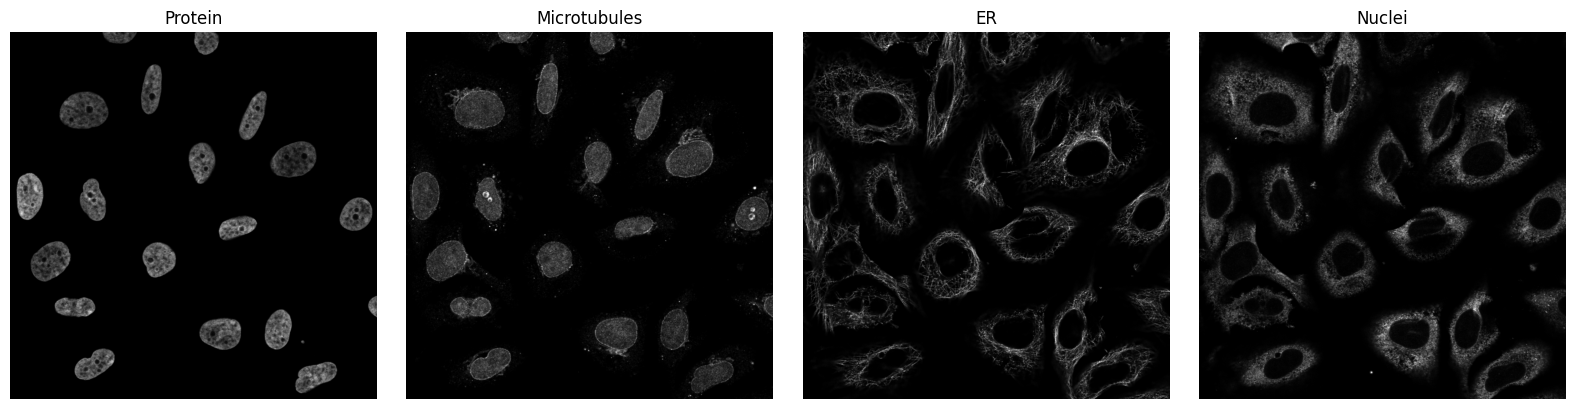

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
channel_names = ["Protein", "Microtubules", "ER", "Nuclei"]
for i in range(4):
    axes[i].imshow(sample_img[i], cmap="gray")
    axes[i].set_title(channel_names[i])
    axes[i].axis("off")
plt.tight_layout()

## Microsim Simulation

Simulate confocal microscopy acquisition using microsim. Each CellAtlas image serves as ground truth, and microsim forward-models the imaging process including PSF convolution and detector noise.

In [ ]:
def simulate_image(img_path):
    gt = tifffile.imread(img_path)
    gt_channel = gt[2].astype(np.float32)
    gt_channel = gt_channel / 255.0 * 2.0
    gt_channel = gt_channel[np.newaxis, :, :]
    egfp_like = ms.Fluorophore.from_fpbase("EGFP")
    
    sim = ms.Simulation.from_ground_truth(
        ground_truth=gt_channel,
        scale=(0.1, 0.1, 0.1), 
        output_space={"downscale": (1, 4, 4)},  
        modality=ms.Confocal(pinhole_au=1.0),
        detector=ms.CameraCCD(
            qe=0.7,          
            read_noise=30,   
            bit_depth=16,
            offset=100,
            dark_current=0.01, 
        ),
        exposure_ms=20, 
    )
    
    sim.sample.labels[0].fluorophore = egfp_like
    result = sim.digital_image(exposure_ms=100)
    
    # Ground truth
    gt_downscaled_float = gt[2].astype(np.float32)[::4, ::4]
    
    return result.values.squeeze(), gt_downscaled_float

# Simulating training data
train_data = [simulate_image(f) for f in train_files]
train_noisy = np.array([d[0] for d in train_data])
train_gt = np.array([d[1] for d in train_data])

# Simulating test data
test_data = [simulate_image(f) for f in test_files]
test_noisy = np.array([d[0] for d in test_data])
test_gt = np.array([d[1] for d in test_data])


## Visualize Simulated Data

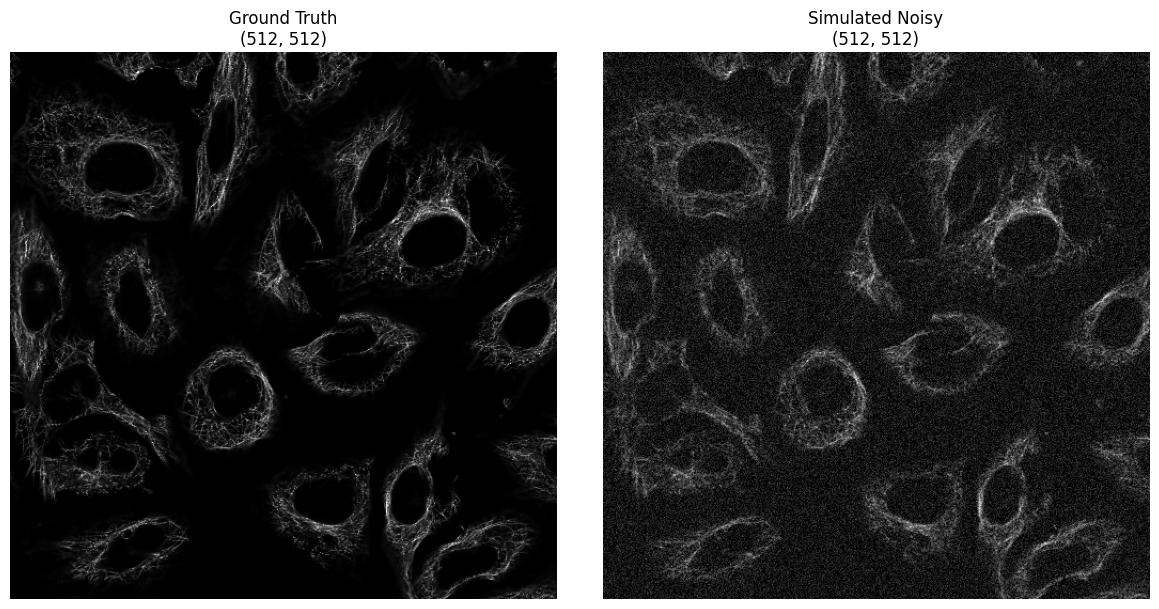

In [45]:
idx = 0
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(train_gt[idx], cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Ground Truth\n{train_gt[idx].shape}")
axes[0].axis("off")

axes[1].imshow(train_noisy[idx], cmap="gray")
axes[1].set_title(f"Simulated Noisy\n{train_noisy[idx].shape}")
axes[1].axis("off")

plt.tight_layout()

## Normalize Data

In [34]:
train_noisy_float = train_noisy.astype(np.float32)
test_noisy_float = test_noisy.astype(np.float32)
test_gt_float = test_gt.astype(np.float32)

In [ ]:
train_noisy_float = train_noisy.astype(np.float32)
test_noisy_float = test_noisy.astype(np.float32)
test_gt_float = test_gt.astype(np.float32)

## Create N2V Configuration

In [36]:
config = create_n2v_configuration(
    experiment_name="cellatlas_microsim_n2v",
    data_type="array",
    axes="SYX",
    patch_size=[128, 128],
    batch_size=32,
    num_epochs=100,
    independent_channels=True,
)

## Train N2V

In [37]:
val_size = len(train_noisy_float) // 5
careamist = CAREamist(config)
careamist.train(
    train_source=train_noisy_float,
    val_source=train_noisy_float[:val_size],
)

No working directory provided. Using current working directory: /home/diya.srivastava/Desktop/repos/careamics-examples/applications/n2v/2D.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Computed dataset mean: [231.08263], std: [221.85847]
/home/diya.srivastava/Desktop/careamics/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/diya.srivastava/Desktop/repos/careamics-examples/applications/n2v/2D/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ UNet │  333 K │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 333 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 333 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 13:  82%|████████▏ | 206/250 [00:13<00:02, 14.98it/s, train_loss_step=0.264, val_loss=0.276, train_loss_epoch=0.29] 

Epoch 99: 100%|██████████| 250/250 [00:13<00:00, 18.18it/s, train_loss_step=0.318, val_loss=0.276, train_loss_epoch=0.281]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 250/250 [00:13<00:00, 18.18it/s, train_loss_step=0.318, val_loss=0.276, train_loss_epoch=0.281]


## Predict

In [38]:
prediction = careamist.predict(
    source=test_noisy_float,
    data_type="array",
    tile_size=(256, 256),
    tile_overlap=(48, 48),
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/diya.srivastava/Desktop/careamics/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 180/180 [00:00<00:00, 244.72it/s]


## Visualize Results

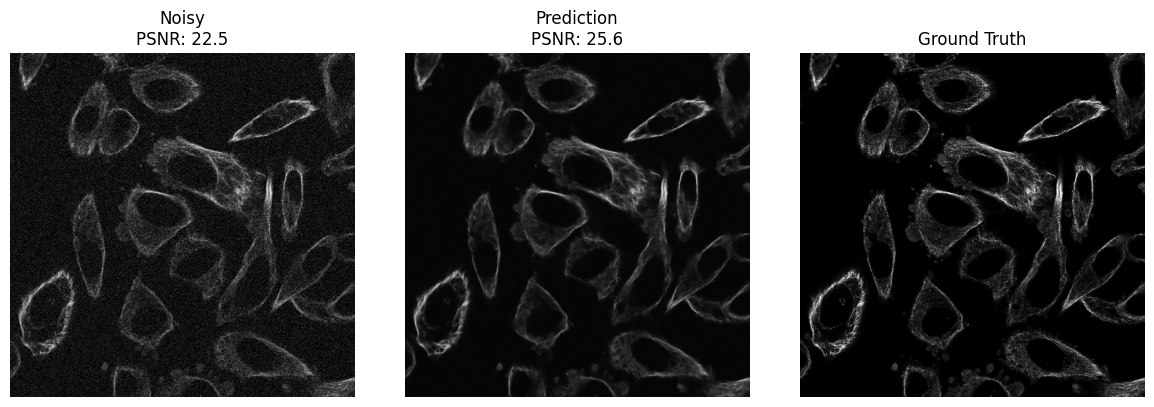

In [46]:
idx = 0
pred = prediction[idx].squeeze()

psnr_noisy = scale_invariant_psnr(test_gt_float[idx], test_noisy_float[idx])
psnr_pred = scale_invariant_psnr(test_gt_float[idx], pred)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(test_noisy_float[idx], cmap="gray")
axes[0].set_title(f"Noisy\nPSNR: {psnr_noisy:.1f}")
axes[0].axis("off")

axes[1].imshow(pred, cmap="gray")
axes[1].set_title(f"Prediction\nPSNR: {psnr_pred:.1f}")
axes[1].axis("off")

axes[2].imshow(test_gt_float[idx], cmap="gray")
axes[2].set_title("Ground Truth")
axes[2].axis("off")

plt.tight_layout()

### Let's inspect more closely

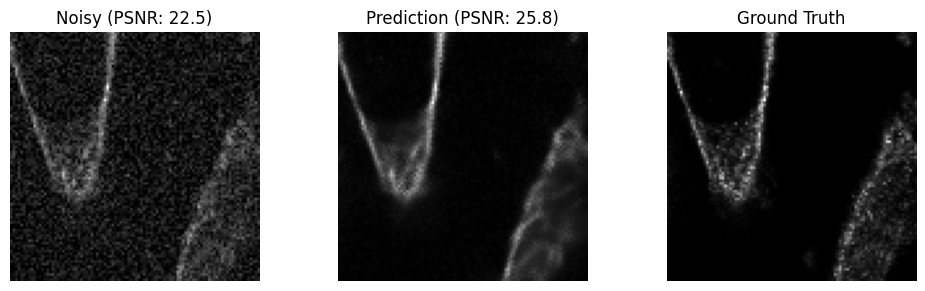

In [51]:
py, px, psize = 300, 100, 96

y_slice = slice(py, py + psize)
x_slice = slice(px, px + psize)

noisy_p = test_noisy_float[0][y_slice, x_slice]
pred_p = prediction[0].squeeze()[y_slice, x_slice]
gt_p = test_gt_float[0][y_slice, x_slice]

psnr_noisy = scale_invariant_psnr(gt_p, noisy_p)
psnr_pred = scale_invariant_psnr(gt_p, pred_p)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(noisy_p, cmap="gray")
axes[0].set_title(f"Noisy (PSNR: {psnr_noisy:.1f})")
axes[0].axis("off")

axes[1].imshow(pred_p, cmap="gray")
axes[1].set_title(f"Prediction (PSNR: {psnr_pred:.1f})")
axes[1].axis("off")

axes[2].imshow(gt_p, cmap="gray")
axes[2].set_title("Ground Truth")
axes[2].axis("off")

plt.tight_layout()

## Create Cover Image

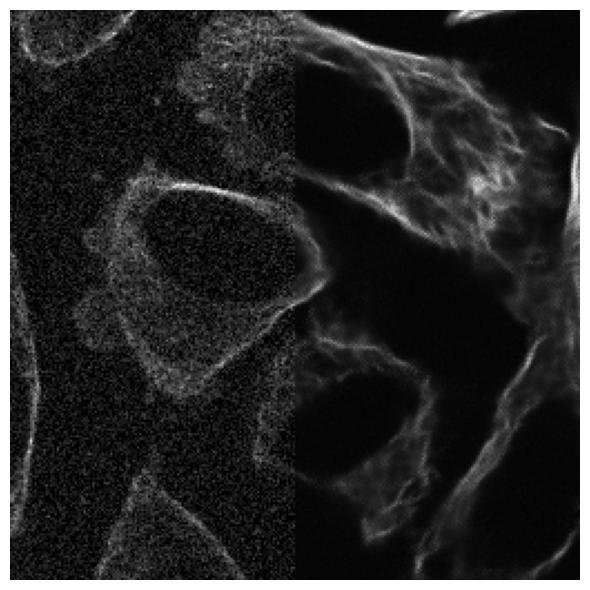

In [42]:
im_idx = 0

# Normalize noisy and prediction separately to [0, 1]
norm_noisy = (test_noisy_float[im_idx] - test_noisy_float[im_idx].min()) / \
             (test_noisy_float[im_idx].max() - test_noisy_float[im_idx].min())
norm_pred = (prediction[im_idx].squeeze() - prediction[im_idx].min()) / \
            (prediction[im_idx].max() - prediction[im_idx].min())

height, width = norm_noisy.shape
cover = np.zeros((256, 256))

cover[:, :128] = norm_noisy[
    height // 2 - 128 : height // 2 + 128,
    width // 2 - 128 : width // 2
]
cover[:, 128:] = norm_pred[
    height // 2 - 128 : height // 2 + 128,
    width // 2 : width // 2 + 128
]

fig = plt.figure(figsize=(6, 6))
plt.imshow(cover, cmap="gray")
plt.axis("off")
plt.tight_layout()

im = Image.fromarray((cover * 255).astype(np.uint8))
im = im.convert("L")
im.save("CellAtlas_microsim_N2V.jpeg")

## Export Model

In [ ]:
general_description = (
    "UNet trained with N2V to denoise confocal microscopy images simulated from "
    "Human Protein Atlas CellAtlas data using microsim."
)

careamist.export_to_bmz(
    path_to_archive="cellatlas_microsim_n2v_model.zip",
    friendly_model_name="CellAtlas_Microsim_N2V",
    input_array=norm_noisy[np.newaxis, :256, :256],
    authors=[{"name": "CAREamics authors", "affiliation": "Human Technopole"}],
    general_description=general_description,
    data_description="Confocal microscopy simulated from HPA CellAtlas immunofluorescence images"
)